In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [2]:
df = pd.read_csv( "../data/processed/cleaned_online_retail.csv", parse_dates=["InvoiceDate"])

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [3]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month_name()
df["MonthNumber"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Year,Month,MonthNumber,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,December,12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,December,12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,December,12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,December,12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,December,12,Wednesday,8


In [4]:
total_revenue = df["TotalAmount"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $8,887,226.89


In [5]:
total_orders = df["Invoice"].nunique()

print(total_orders)

18532


In [6]:
total_customers = df["Customer ID"].nunique()

print(total_customers)

4338


In [7]:
total_products = df["StockCode"].nunique()

print(total_products)

3665


In [8]:
avg_order = total_revenue / total_orders

print(f"Average Order Value: ${avg_order:.2f}")

Average Order Value: $479.56


In [9]:
monthly_sales = (df.groupby("MonthNumber")["TotalAmount"].sum().reset_index())

monthly_sales

,MonthNumber,TotalAmount
0,1,568101.31
1,2,446084.92
2,3,594081.76
3,4,468374.33
4,5,677355.15
5,6,660046.05
6,7,598962.90
7,8,644051.04
8,9,950690.20
9,10,1035642.45


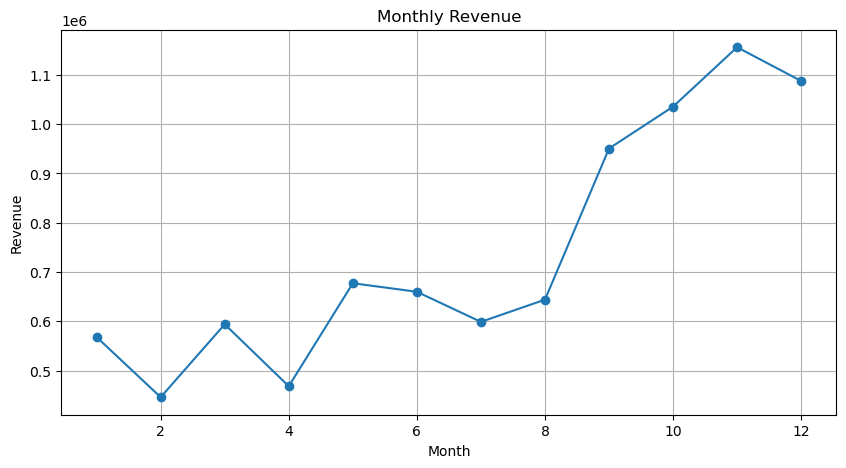

In [10]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["MonthNumber"],
    monthly_sales["TotalAmount"],
    marker="o"
)

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [11]:
country_sales = (
    df.groupby("Country")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_sales

Country
United Kingdom   7285024.64
Netherlands       285446.34
EIRE              265262.46
Germany           228678.40
France            208952.31
Australia         138453.81
Spain              61558.56
Switzerland        56443.95
Belgium            41196.34
Sweden             38367.83
Name: TotalAmount, dtype: float64

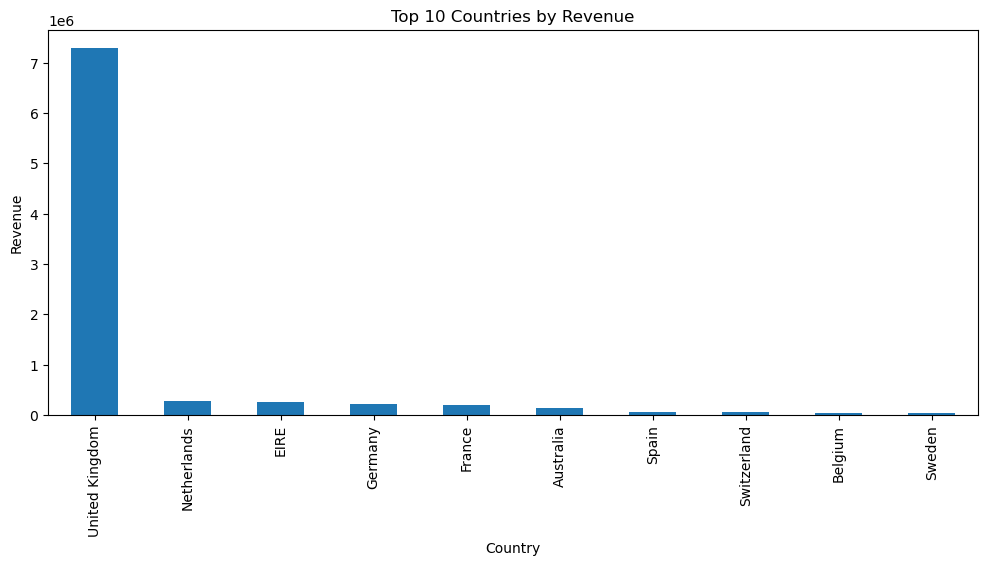

In [12]:
country_sales.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 10 Countries by Revenue")

plt.ylabel("Revenue")

plt.show()

In [13]:
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

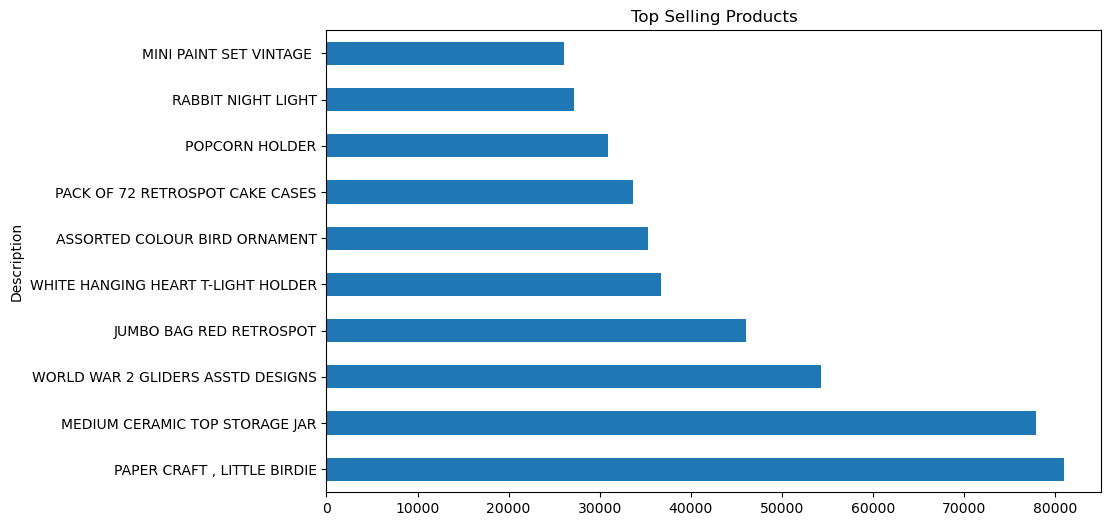

In [14]:
top_products.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top Selling Products")

plt.show()

In [15]:
top_customers = (
    df.groupby("Customer ID")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

Customer ID
14646   280206.02
18102   259657.30
17450   194390.79
16446   168472.50
14911   143711.17
12415   124914.53
14156   117210.08
17511    91062.38
16029    80850.84
12346    77183.60
Name: TotalAmount, dtype: float64

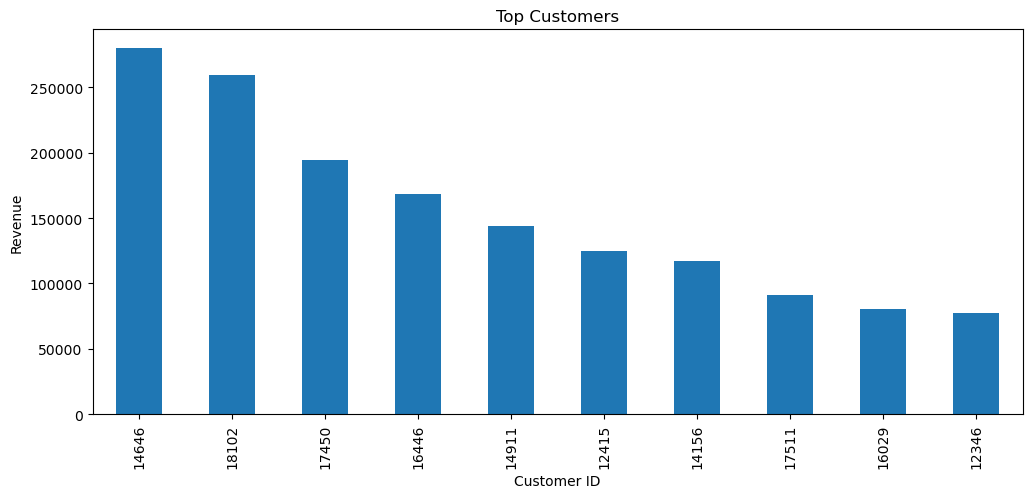

In [16]:
top_customers.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top Customers")

plt.ylabel("Revenue")

plt.show()

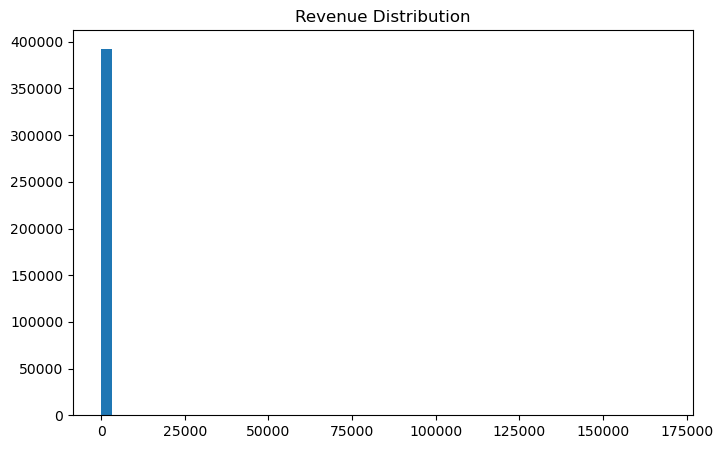

In [17]:
plt.figure(figsize=(8,5))

plt.hist(
    df["TotalAmount"],
    bins=50
)

plt.title("Revenue Distribution")

plt.show()

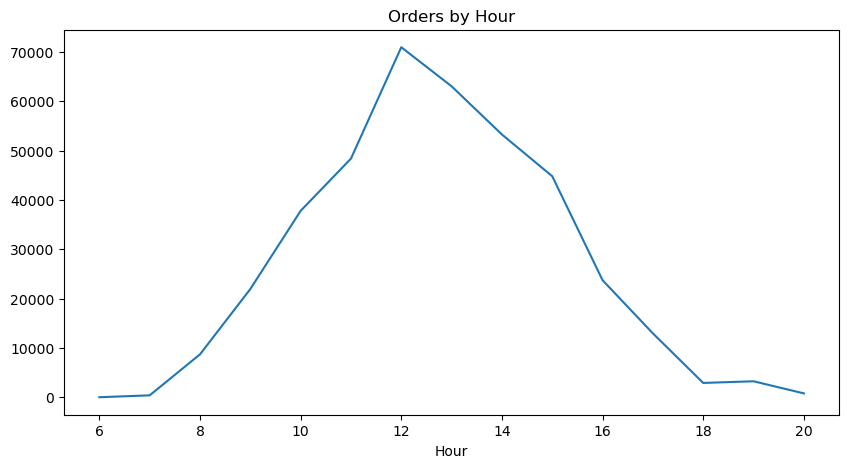

In [18]:
hourly_orders = (
    df.groupby("Hour")["Invoice"]
      .count()
)

hourly_orders.plot(
    figsize=(10,5)
)

plt.title("Orders by Hour")

plt.show()

In [19]:
top_revenue_products = (
    df.groupby("Description")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_revenue_products

Description
PAPER CRAFT , LITTLE BIRDIE          168469.60
REGENCY CAKESTAND 3 TIER             142264.75
WHITE HANGING HEART T-LIGHT HOLDER   100392.10
JUMBO BAG RED RETROSPOT               85040.54
MEDIUM CERAMIC TOP STORAGE JAR        81416.73
POSTAGE                               77821.96
PARTY BUNTING                         68785.23
ASSORTED COLOUR BIRD ORNAMENT         56413.03
Manual                                53419.93
RABBIT NIGHT LIGHT                    51251.24
Name: TotalAmount, dtype: float64

In [20]:
purchase_frequency = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
)

purchase_frequency.describe()

count   4338.00
mean       4.27
std        7.70
min        1.00
25%        1.00
50%        2.00
75%        5.00
max      209.00
Name: Invoice, dtype: float64

In [21]:
df.to_csv("../data/processed/eda_dataset.csv",index=False)